In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/dt_simulated_weekly.csv")
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE').reset_index(drop=True)

# Define your column groups
MEDIA_SPEND_COLS = ['tv_S', 'ooh_S', 'print_S', 'facebook_S', 'search_S']
TARGET = 'revenue'
DATE   = 'DATE'

In [ ]:
# ── Block 1: Summary statistics ───────────────────────────────────────
print("DATASET SUMMARY")
print(f"Weeks: {df.shape[0]}")
print(f"Date range: {df[DATE].min().date()} to {df[DATE].max().date()}")
print(f"\nRevenue statistics:")
print(df[TARGET].describe().round(0))
print(f"\nMedia spend statistics:")
print(df[MEDIA_SPEND_COLS].describe().round(0))

_____DATASET SUMMARY_____
Weeks: 208
Date range: 2015-11-23 to 2019-11-11

Revenue statistics:
count        208.0
mean     1822143.0
std       716229.0
min       672250.0
25%      1165211.0
50%      1874514.0
75%      2378407.0
max      3827520.0
Name: revenue, dtype: float64

Media spend statistics:
           tv_S     ooh_S  print_S  facebook_S  search_S
count     208.0     208.0    208.0       208.0     208.0
mean    14844.0   43218.0   3729.0      2146.0    5916.0
std     28558.0   83991.0   6483.0      3160.0    4703.0
min         0.0       0.0      0.0         0.0       0.0
25%         0.0       0.0      0.0         0.0    2353.0
50%         0.0       0.0      0.0         0.0    4807.0
75%     18407.0   50858.0   4768.0      3623.0    8537.0
max    158047.0  500362.0  31922.0     15400.0   17880.0


In [ ]:
# ── Block 4: Media spend over time (all channels) ─────────────────────
import matplotlib.dates as mdates

fig, axes = plt.subplots(len(MEDIA_SPEND_COLS), 1, figsize=(14, 14), sharex=True)
colours = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

quarter_starts = pd.date_range(start=df[DATE].min(), end=df[DATE].max(), freq='QS')

for i, (col, colour) in enumerate(zip(MEDIA_SPEND_COLS, colours)):
    axes[i].plot(df[DATE], df[col], linewidth=1.0, color=colour)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel("Spend (£)")
    for qdate in quarter_starts:
        axes[i].axvline(qdate, color='grey', linewidth=0.5, linestyle='--', alpha=0.5)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[-1].tick_params(axis='x', rotation=45)

plt.suptitle("Weekly Media Spend by Channel", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../data/processed/media_spend_timeseries.png", dpi=150)
plt.show()

In [ ]:
# ── Block 2: Budget share by channel ─────────────────────────────────
total_by_channel = df[MEDIA_SPEND_COLS].sum()
budget_share = (total_by_channel / total_by_channel.sum() * 100).round(1)

print("BUDGET SHARE BY CHANNEL")
for channel, share in budget_share.sort_values(ascending=False).items():
    print(f"  {channel:<15} {share}%")

BUDGET SHARE BY CHANNEL
  ooh_S           61.9%
  tv_S            21.3%
  search_S        8.5%
  print_S         5.3%
  facebook_S      3.1%


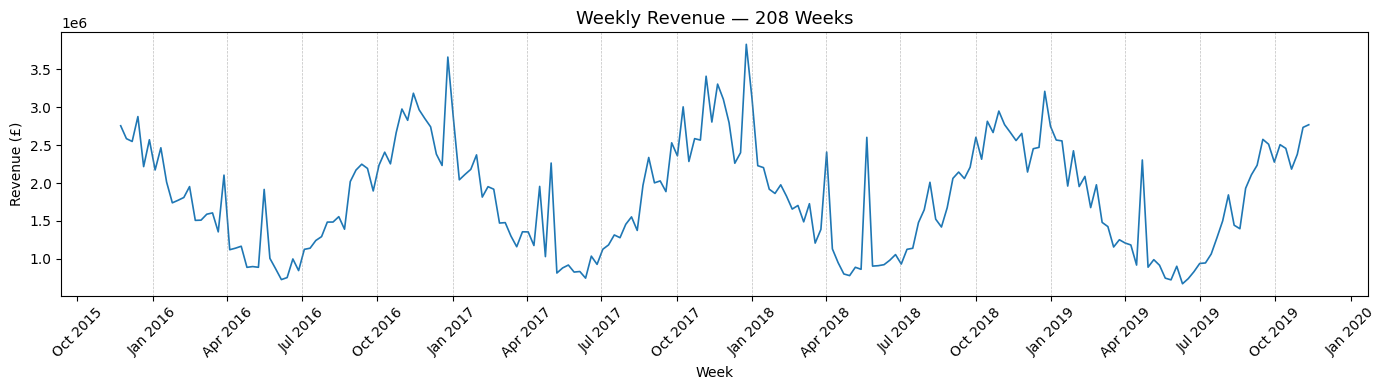

In [23]:
# ── Block 3: Revenue over time ────────────────────────────────────────
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df[DATE], df[TARGET], linewidth=1.2, color='#1f77b4')
ax.set_title("Weekly Revenue — 208 Weeks", fontsize=13)
ax.set_xlabel("Week")
ax.set_ylabel("Revenue (£)")

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)

# Vertical lines at every quarter
import pandas as pd
quarter_starts = pd.date_range(start=df[DATE].min(), end=df[DATE].max(), freq='QS')
for qdate in quarter_starts:
    ax.axvline(qdate, color='grey', linewidth=0.5, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("../data/processed/revenue_timeseries.png", dpi=150)
plt.show()

From what i can see here, there's usually a spike just before a new year.

There is another spike in the middle and towards the end of the Q2 of every year. 

Then there is always an immediate crash immediately after the spike in revenue in Q2. 

It then steadility increases again until the end of Q4 when it has another huge spike and then a steady and gradual drop until Q2 again.

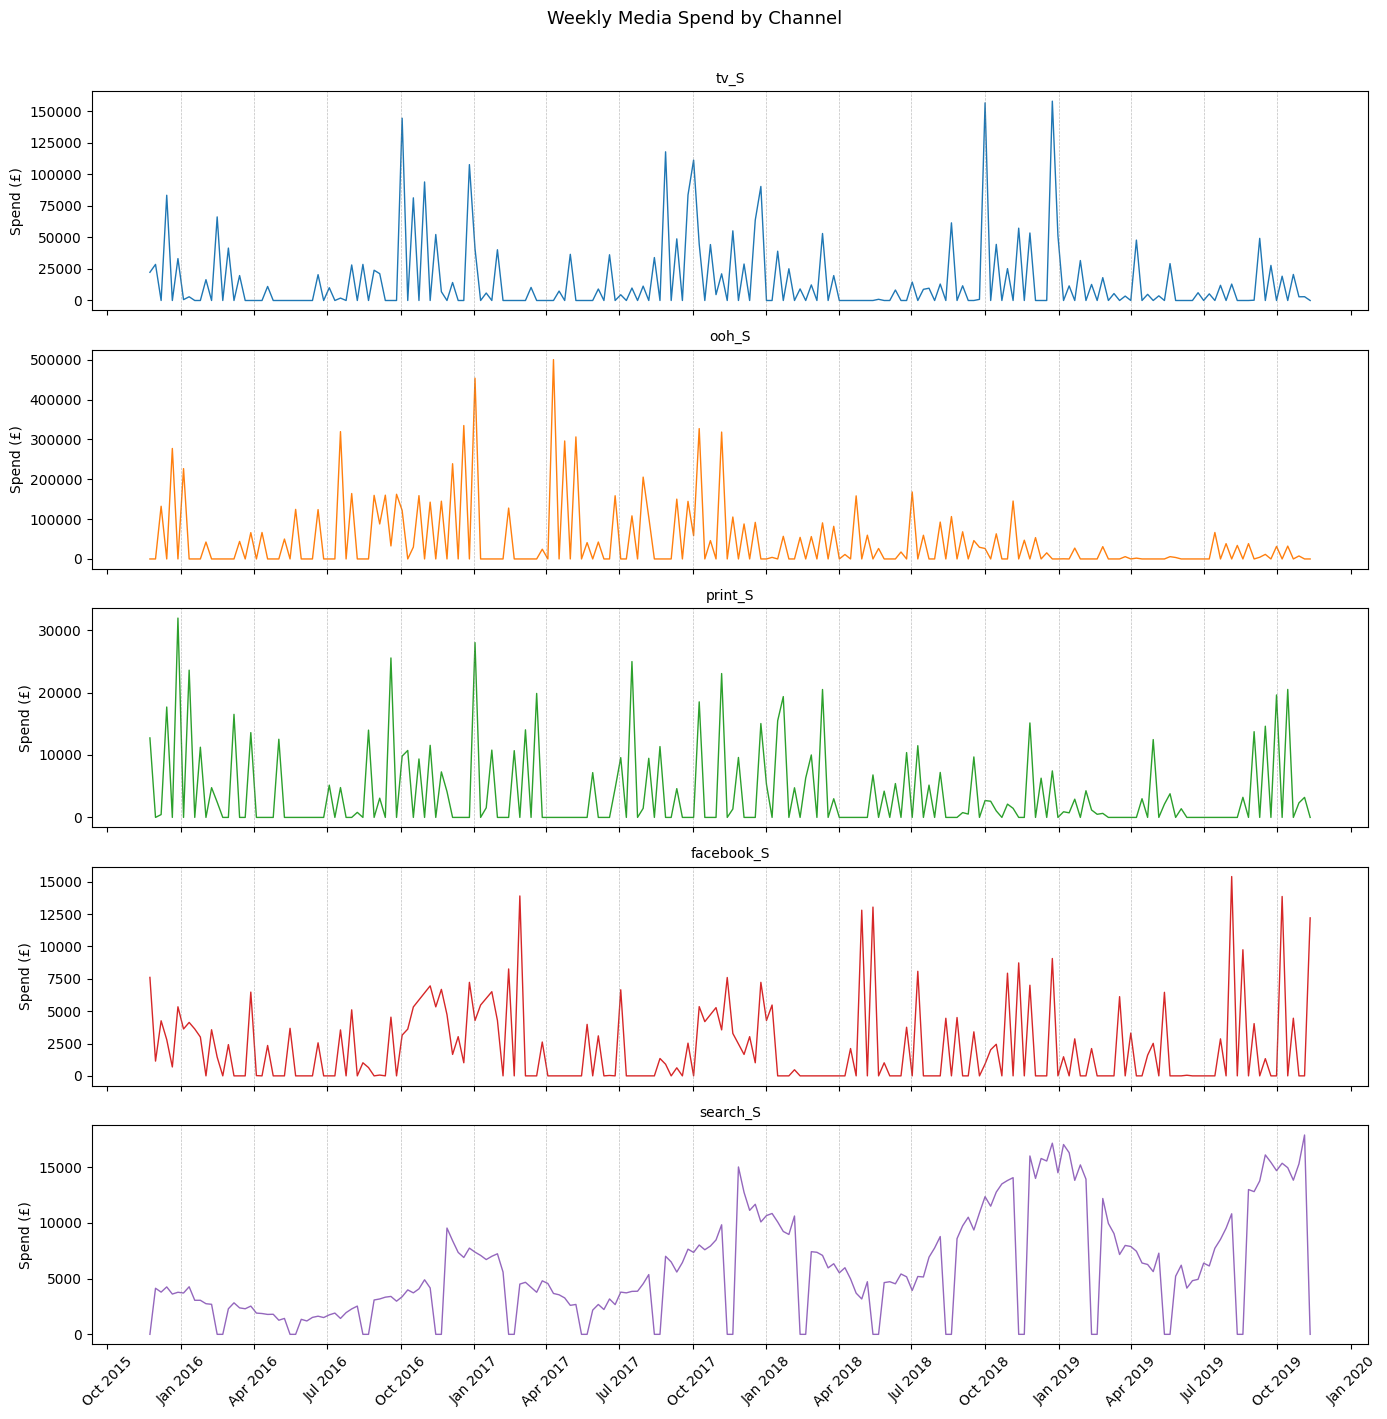

In [27]:
# ── Block 4: Media spend over time (all channels) ─────────────────────
fig, axes = plt.subplots(len(MEDIA_SPEND_COLS), 1, figsize=(14, 14), sharex=True)
colours = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

quarter_starts = pd.date_range(start=df[DATE].min(), end=df[DATE].max(), freq='QS')

for i, (col, colour) in enumerate(zip(MEDIA_SPEND_COLS, colours)):
    axes[i].plot(df[DATE], df[col], linewidth=1.0, color=colour)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel("Spend (£)")
    for qdate in quarter_starts:
        axes[i].axvline(qdate, color='grey', linewidth=0.5, linestyle='--', alpha=0.5)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)

plt.suptitle("Weekly Media Spend by Channel", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../data/processed/media_spend_timeseries.png", dpi=150)
plt.show()

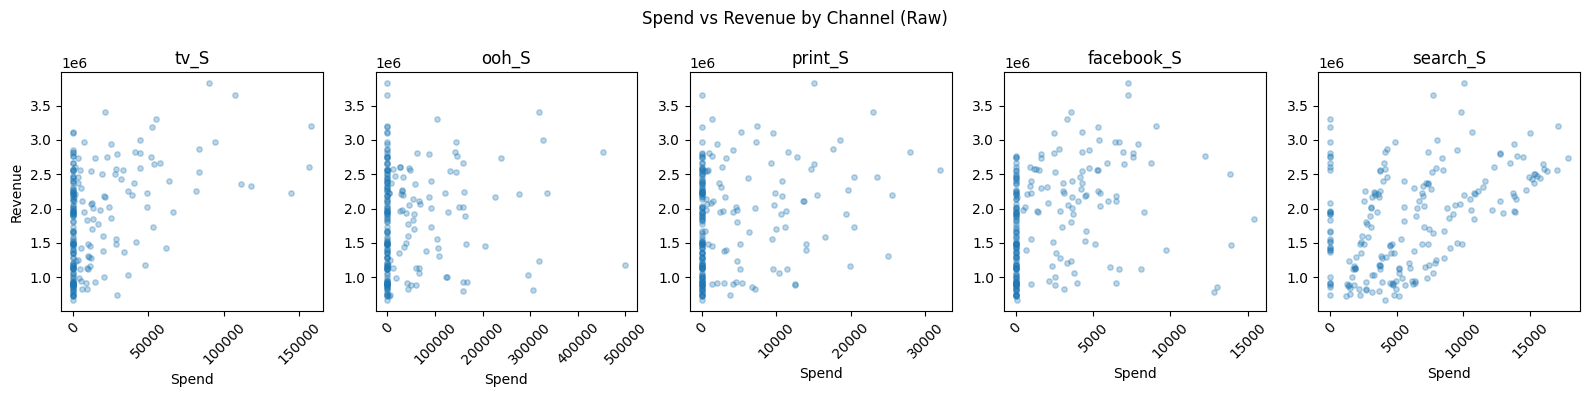

In [34]:
# ── Block 6: Spend vs revenue scatter (per channel) ───────────────────
fig, axes = plt.subplots(1, len(MEDIA_SPEND_COLS), figsize=(16, 4))

for i, col in enumerate(MEDIA_SPEND_COLS):
    axes[i].scatter(df[col], df[TARGET], alpha=0.3, s=15)
    axes[i].set_title(col)
    axes[i].set_xlabel("Spend")
    axes[i].tick_params(axis='x', rotation=45)
    if i == 0:
        axes[i].set_ylabel("Revenue")
        
plt.xticks(rotation=45)
plt.suptitle("Spend vs Revenue by Channel (Raw)", fontsize=12)
plt.tight_layout()
plt.savefig("../data/processed/spend_vs_revenue_scatter.png", dpi=150)
plt.show()

From what i can see, tv_S and ooh_S, didn't really have much effect on revenue or spending more on it didn't really change anything.

From print_S and facebook_S, you can see that spending more on it had an effect on revenue increase.

Then, search_S, had the most effect. Once could say everytime a customer saw a search add, they mostly settled to buy.